In [1]:
import csv
import pandas as pd
import re
import os
from bs4 import BeautifulSoup
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from huggingface_hub import login
from dotenv import load_dotenv
import yfinance as yf
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt



load_dotenv()
token = os.getenv('HF_TOKEN')
login(token)


c:\Users\hmaxw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [2]:
News_api_data = pd.read_csv('NewsAPI_data.csv',encoding='utf-8')
guardian_data = pd.read_csv('guardian_data.csv',encoding='utf-8')
guardian_data = guardian_data.rename(columns={'headline': 'title', 'body_text': 'content'}, inplace=True)
news = pd.concat([guardian_data,News_api_data])
news['date'] = pd.to_datetime(news['date'], format='%Y%m%d')

brent = pd.read_csv('Brent_data.csv',encoding='utf-8')
brent['date'] = pd.to_datetime(brent['date'])

wti = pd.read_csv('WTI_data.csv',encoding='utf-8')
wti['date'] = pd.to_datetime(wti['date'])

ovx = pd.read_csv('ovx_data.csv',encoding='utf-8')
ovx['date'] = pd.to_datetime(ovx['date'])

vix = pd.read_csv('vix_data.csv',encoding='utf-8')
vix['date'] = pd.to_datetime(vix['date'])


In [3]:
prosus_model= AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')
prosus_tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')


nlp1 = pipeline('text-classification', model=prosus_model, tokenizer=prosus_tokenizer, truncation=True, max_length=512,batch_size=32)

def sentiment(texts):
    results1 = nlp1([i if isinstance(i, str) and i.strip() else ' ' for i in texts])
    return [ i['score'] if i['label'] == 'positive' else -i['score'] if i['label'] == 'negative' else 0 for i in results1] 

news['title_score_prosus'] = sentiment(news['title'])
news['content_score_prosus'] = sentiment(news['content'])
news['final_score_prosus'] = news[['title_score_prosus','content_score_prosus']].mean(axis=1)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 26471.21it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
news.to_csv('important_one.csv', index=False, encoding='utf-8')

In [5]:
sentiment_by_day = pd.DataFrame(news.groupby('date')['final_score_prosus'].agg(['mean','std','count']))
sentiment_by_day.reset_index(inplace=True)

In [7]:
pre_complete1 = pd.merge(sentiment_by_day, brent ,on='date', how='inner')
pre_complete2 = pd.merge(pre_complete1, wti,on='date', how='inner')
pre_complete3 = pd.merge(pre_complete2, vix,on='date', how='inner')
pre_complete3 = pre_complete3.rename(columns={'mean': 'sentiment_mean','std': 'sentiment_std','daily_avg_x': 'brent','daily_avg_y': 'wti','daily_avg': 'vix'})
complete = pd.merge(pre_complete3, ovx,on='date', how='inner')
complete = complete.rename(columns={'daily_avg':'ovx'})

In [22]:
complete['mean_moving_average'] = complete['sentiment_mean'].rolling(window=3).mean()
complete['mean_moving_average_inversed'] = -(complete['mean_moving_average'])
complete['mean_moving_average_inversed_lagged'] = complete['mean_moving_average_inversed'].shift(2)
complete['sentiment_mean_inversed'] = -(complete['sentiment_mean'])
complete['ovx_moving_average'] = complete['ovx'].rolling(window=3).mean()
complete['vix_moving_average'] = complete['vix'].rolling(window=3).mean()
complete['vix_moving_average_lagged'] = complete['vix_moving_average'].shift(2)
complete['lagged_brent'] = complete['brent'].shift(2)


In [19]:
complete

,date,sentiment_mean,sentiment_std,count,brent,wti,vix,ovx,mean_moving_average,mean_moving_average_inversed,mean_moving_average_inversed_lagged,ovx_moving_average,vix_moving_average,vix_moving_average_lagged,lagged_brent
0,2026-03-02,-0.353267,0.453956,44,77.369999,73.115002,23.050000,71.420002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-03,-0.275245,0.591441,29,79.725002,72.895000,24.070000,75.770000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-04,-0.264785,0.560397,23,81.650002,74.700001,22.770000,77.064999,-0.297766,0.297766,NaN,74.751667,23.296666,NaN,77.369999
3,2026-03-05,-0.415485,0.538649,21,83.920002,78.580002,22.930000,81.360001,-0.318505,0.318505,NaN,78.065000,23.256667,NaN,79.725002
4,2026-03-06,-0.191188,0.634110,37,88.764999,84.990002,26.345000,98.055000,-0.290486,0.290486,0.297766,85.493333,24.015000,23.296666,81.650002
5,2026-03-09,-0.202739,0.506470,50,98.660000,96.384998,30.309999,106.130001,-0.269804,0.269804,0.318505,95.181667,26.528333,23.256667,83.920002
6,2026-03-10,-0.320946,0.506929,37,90.125000,84.599998,24.660000,106.855000,-0.238291,0.238291,0.290486,103.680000,27.105000,24.015000,88.764999
7,2026-03-11,-0.058522,0.531797,28,91.640003,87.070000,24.565000,114.970001,-0.194069,0.194069,0.269804,109.318334,26.511666,26.528333,98.660000
8,2026-03-12,-0.367885,0.508667,34,97.099998,92.525002,26.385000,122.060001,-0.249117,0.249117,0.238291,114.628334,25.203333,27.105000,90.125000
9,2026-03-13,-0.344144,0.520924,28,102.400002,97.724998,27.520000,116.599998,-0.256850,0.256850,0.194069,117.876667,26.156667,26.511666,91.640003


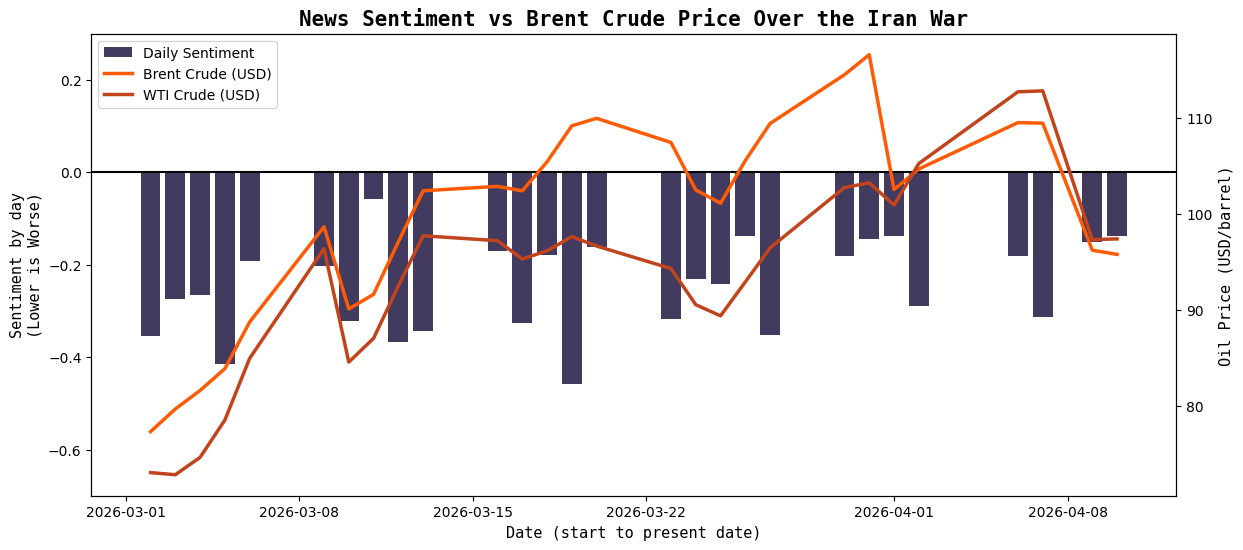

In [29]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(complete['date'], complete['sentiment_mean'], color='#2D244D', alpha=0.9, width=0.8, label='Daily Sentiment')
ax1.axhline(0, color='black')
ax1.set_ylabel('Sentiment by day\n(Lower is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')
ax1.set_ylim(-0.7, 0.3)

ax2 = ax1.twinx()
ax2.plot(complete['date'], complete['brent'], color='#FF5B04', linewidth=2.5, label='Brent Crude (USD)')
ax2.plot(complete['date'], complete['wti'], color='#C2441C', linewidth=2.5, label='WTI Crude (USD)')
ax2.set_ylabel('Oil Price (USD/barrel)', fontsize=11, fontfamily='monospace')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('News Sentiment vs Brent Crude Price Over the Iran War', fontsize=15, fontweight='bold', fontfamily='monospace')
plt.savefig('sentiment_vs_brent_wti.png')
plt.show()

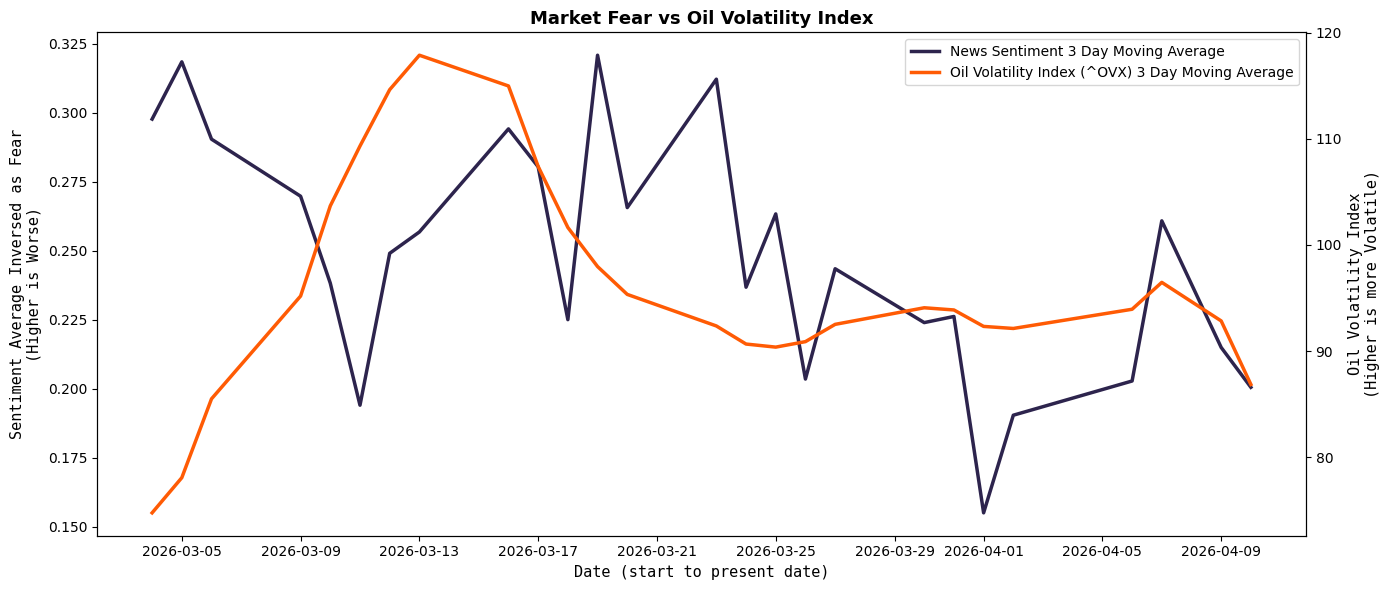

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(complete['date'], complete['mean_moving_average_inversed'], color='#2D244D', linewidth=2.5, label='News Sentiment 3 Day Moving Average')
ax1.set_ylabel('Sentiment Average Inversed as Fear\n(Higher is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')

ax2 = ax1.twinx()
ax2.plot(complete['date'], complete['ovx_moving_average'], color='#FF5B04', linewidth=2.5, label='Oil Volatility Index (^OVX) 3 Day Moving Average')
ax2.set_ylabel('Oil Volatility Index\n(Higher is more Volatile)', fontsize=11, fontfamily='monospace')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Market Fear vs Oil Volatility Index', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

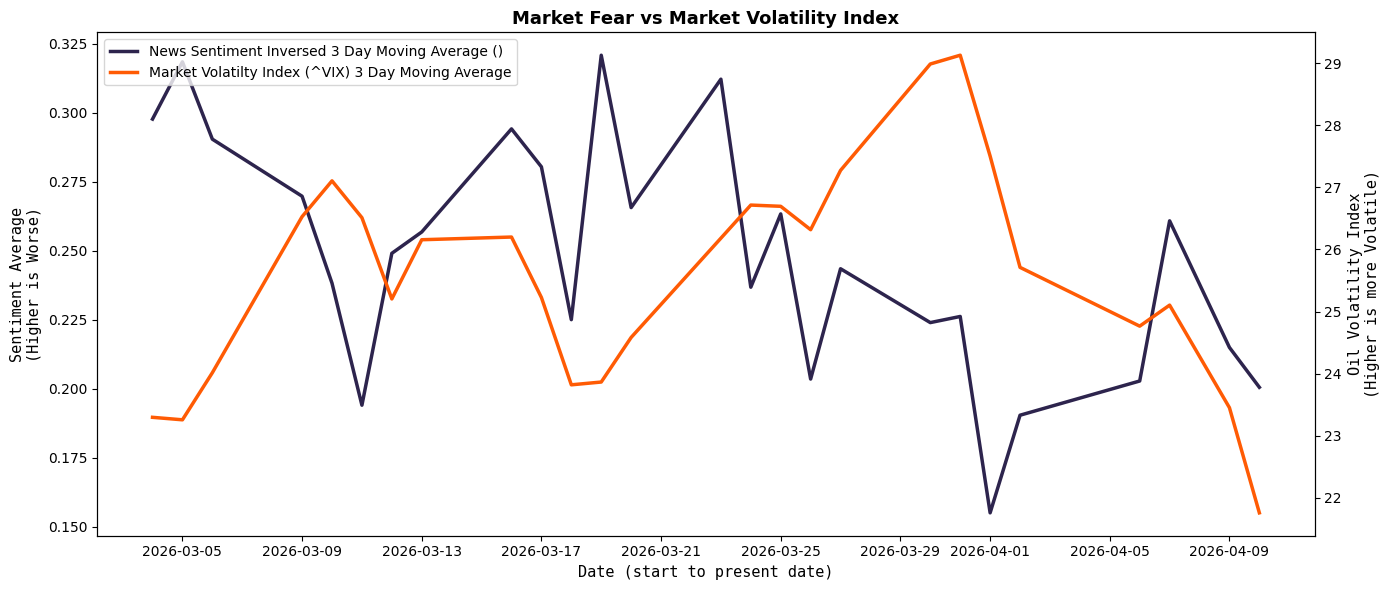

In [32]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(complete['date'], complete['mean_moving_average_inversed'], color='#2D244D', linewidth=2.5, label='News Sentiment Inversed 3 Day Moving Average ()')
ax1.set_ylabel('Sentiment Average\n(Higher is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')

ax2 = ax1.twinx()
ax2.plot(complete['date'], complete['vix_moving_average'], color='#FF5B04', linewidth=2.5, label='Market Volatilty Index (^VIX) 3 Day Moving Average')
ax2.set_ylabel('Oil Volatility Index\n(Higher is more Volatile)', fontsize=11, fontfamily='monospace')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Market Fear vs Market Volatility Index', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

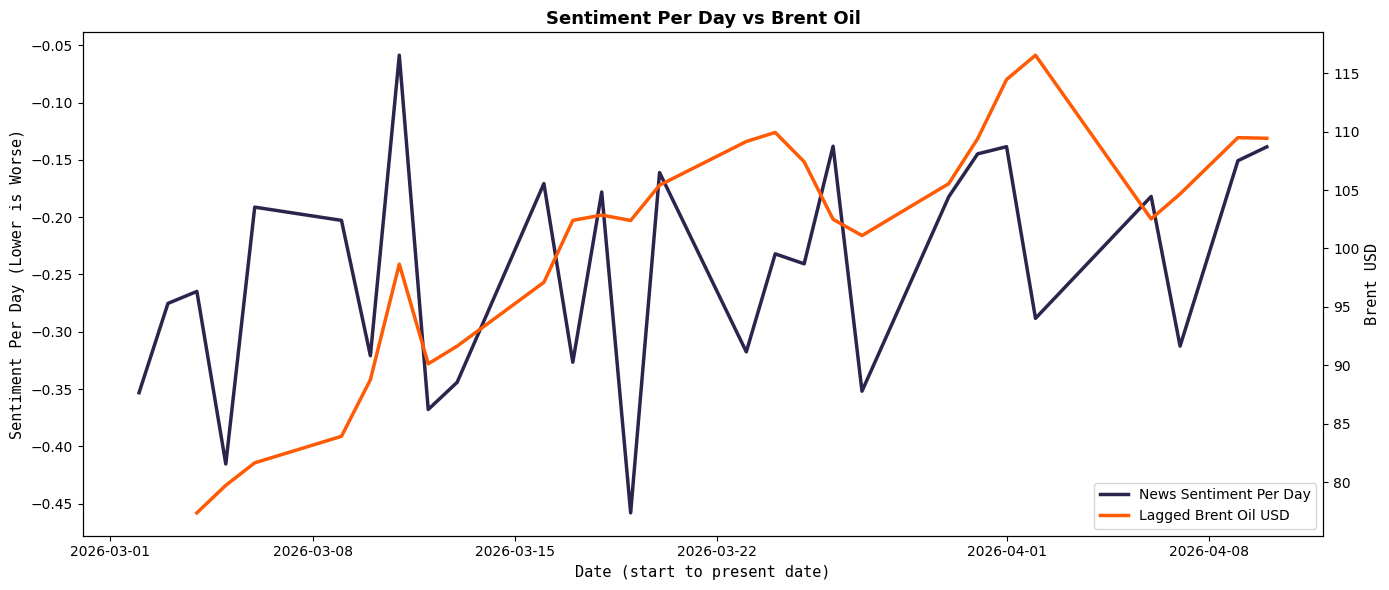

In [14]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(complete['date'], complete['sentiment_mean'], color='#2D244D', linewidth=2.5, label='News Sentiment Per Day')
ax1.set_ylabel('Sentiment Per Day (Lower is Worse)', fontsize=11, fontfamily='monospace')
ax1.set_xlabel('Date (start to present date)', fontsize=11, fontfamily='monospace')

ax2 = ax1.twinx()
ax2.plot(complete['date'], complete['lagged_brent'], color='#FF5B04', linewidth=2.5, label='Lagged Brent Oil USD')
ax2.set_ylabel('Brent USD', fontsize=11, fontfamily='monospace')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Sentiment Per Day vs Brent Oil', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()